# Dinámica y regímenes de mercado en activos a la Teoría de precios de arbitraje (TPA) 

The arbitrage pricing theory (APT) is a multi-factor asset pricing model. It's based on the idea that an asset's returns can be predicted using the linear relationship between the asset’s expected return and several macroeconomic variables that capture systematic risk. It's a useful tool for analyzing portfolios from a *value investing* perspective to identify securities that may be temporarily mispriced.

The main limitation of APT is that the theory doesn't suggest factors for a particular stock or asset. One stock could be more sensitive to one factor than another and investors have to be able to perceive the risk sources and sensitivities.

Our first task will be to suggest potential macroeconomic and stock market factors.
We will develop all the ideas and some code for a better understanding using a *custom class*.

In [169]:
import importlib
import macro_analysis.macro_tools as rrm
importlib.reload(rrm)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math 

The countries of interest are Mexico and United States but this project allows to work with any country.

APT factors are the systematic risk that can't be reduced by the diversification of an investment portfolio. The macroeconomic factors that have proven most reliable as price predictors include:
1. **Unexpected** changes in inflation - UN_INF
2. Gross national product (GNP) - 
3. Corporate bond *spreads* - 
4. Shifts in the yield curve - T10Y2Y (10Y − 2Y spread), T10Y3M (closely followed by the Fed as a sign of recession)
5. Gross domestic product (GDP)
6. Commodities prices
7. Market indices
8. Exchange rates.

By our previous analysis, we will even work with the follwing factors:
* Exected inflation by horizonts (3/10 for Mexico and 5/10 for United States)
* Real and nominal rates.
* General annual, monthly and current growth of México and US Consumer Price Index.

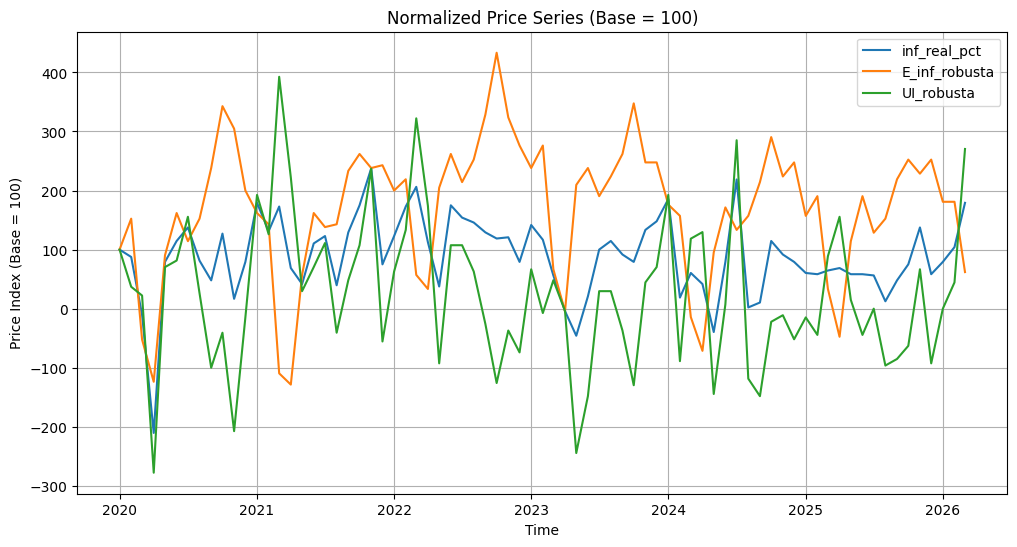

In [43]:
# Unexpected changes in inflation 
rrm.plot_normalized_timeseries_def_columns(['UN_INF', 'UN_INF', 'UN_INF'], ['inf_real_pct', 'E_inf_robusta', 'UI_robusta'], legend = 'Columns')

No data available for UDI20


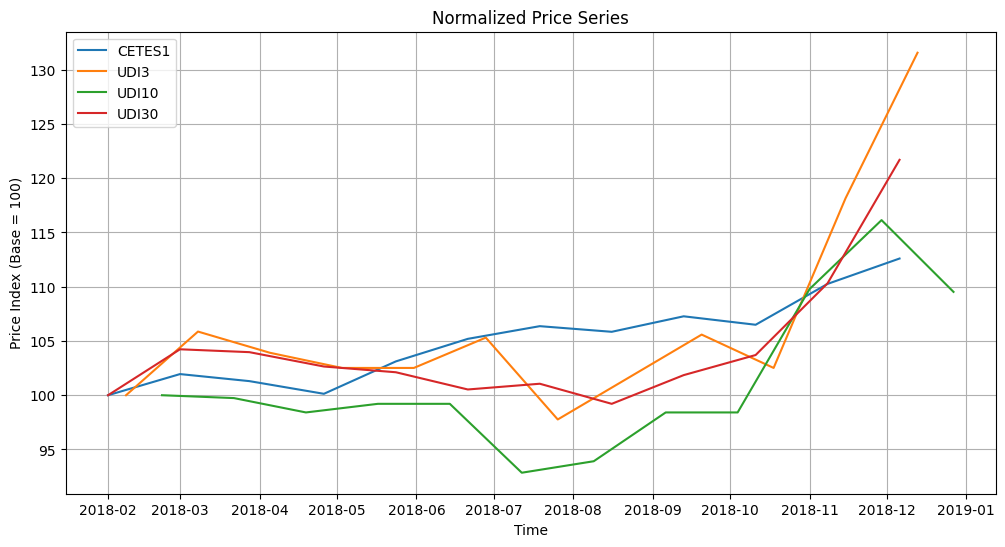

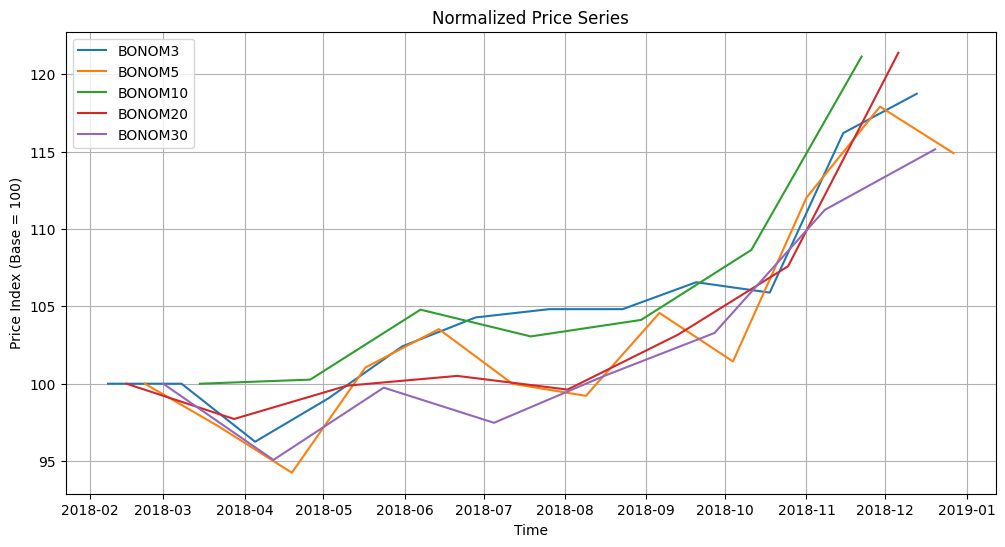

In [73]:
# Shifts in the yield curve
rrm.plot_normalized_timeseries(['CETES1', 'UDI3', 'UDI10', 'UDI20', 'UDI30'], from_date='2018-01-01', to_date='2018-12-31')
rrm.plot_normalized_timeseries(['BONOM3', 'BONOM5', 'BONOM10', 'BONOM20', 'BONOM30'], from_date='2018-01-01', to_date='2018-12-31')

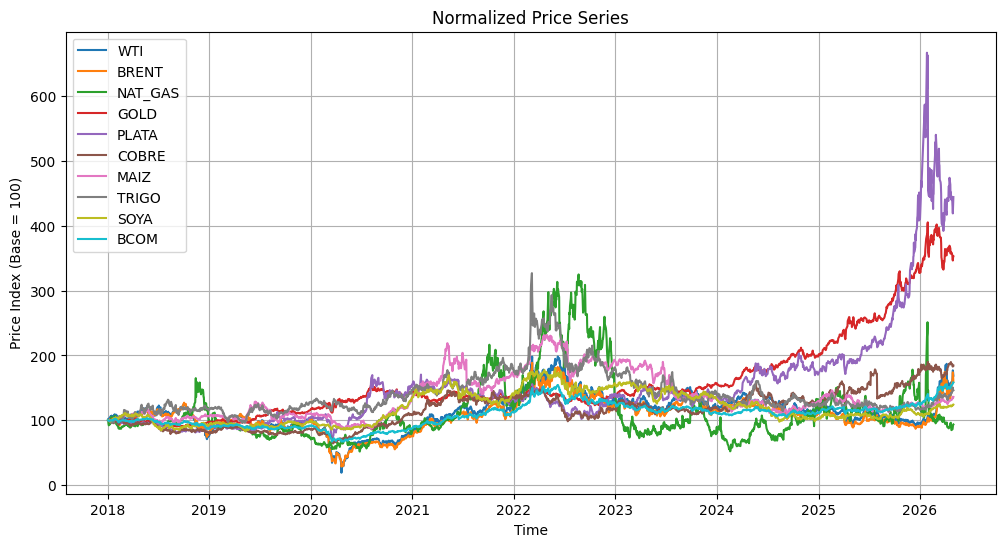

In [68]:
# COMODITIES
rrm.plot_normalized_timeseries(['WTI', 'BRENT', 'NAT_GAS', 'GOLD', 'PLATA', 'COBRE', 'MAIZ', 'TRIGO', 'SOYA', 'BCOM'])

### Assumptions

# Marco Analítico: Búsqueda de Poder Explicativo en Ventanas Temporales Deslizantes

El presente análisis emplea un modelo de regresión lineal simple sobre variables estandarizadas, cuyo objetivo central no es la predicción puntual, sino la **cuantificación sistemática del poder explicativo que una variable ejerce sobre otra a lo largo del tiempo**.

La métrica principal es el coeficiente de determinación r^2, complementado por un Score ponderado que ajusta dicho r^2 por el número de observaciones disponibles en cada ventana, penalizando así las relaciones espurias derivadas de muestras reducidas.

La arquitectura de búsqueda opera mediante ventanas temporales deslizantes no superpuestas en su punto de inicio, generando todas las combinaciones posibles de pares de meses dentro de un año calendario. Para el caso mensual (2018, 2020, 2023, 2025), esto implica construir regresiones desde el par enero–febrero hasta el par noviembre–diciembre, acumulando observaciones progresivamente. 

El criterio mínimo de validez es una ventana de aproximadamente 60 días hábiles de mercado (aprox. 3 meses), garantizando robustez estadística. Para el análisis anual se requieren al menos 200 observaciones por ventana, y para 2026 dada la escasez de datos intra-año la división se reduce a comparaciones semanales con un mínimo de un mes de observaciones.

Los resultados se clasifican en dos bloques por período:

* Principal: el activo que aparece como la variable dependiente con mayor frecuencia de presencia como "benchmark líder" a través de todas las ventanas válidas del período. Representa la relación más consistente y estructural identificada.
* Complemento: los demás activos analizados que, en ese mismo período, exhiben relaciones explicativas secundarias pero estadísticamente relevantes, o cuya presencia parcial sugiere regímenes condicionados.

El uso de UNEXPECTED INFLATION puede ser limitado, casi nulo (B1=0) independientemente de que activo/indices se ocupe para y
Buscar de nuevo la informacion de bonos M, udibonos
Commodities sirven
EXP_INF DE USA Y MX ACTUAL, TIPS, DGS
Index sirven


Dado que nuestra función que busca el mejor r2 fue construida con complejidad algorítmica exponencial O(n^2), los benchmarks serán aplicados por sección de indices, commodities, tasas, etc.

Before starting, let´s see if the unexpected inflation information built is significative for some assets as monthly returns of BBVA, DXY and USDMXN over a simple linear regression model due the small sample that we have at the moment.

Formally, we will check if assuptions are satisfied to make properly the test for b1 (slope). 

Predicted b1 by the model: -6e-05
T test - t* de b1 : -0.565282560167505
Se acepta H0 ( b1  =  0 )
Se rechaza H0 ( b1  >=  0 ) tq b1 < 0 ya que -0.565282560167505 < 1.666293696131535


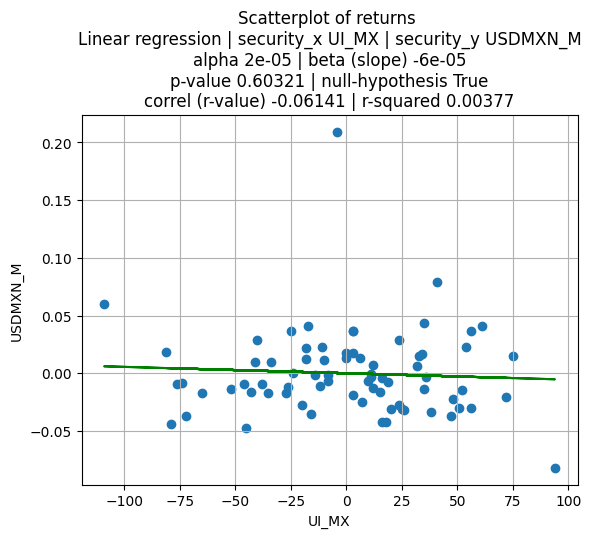

In [120]:
model = rrm.model('UI_MX', 'USDMXN_M', model_type='macro')
model.synchronise_timeseries()
model.compute_linear_reg()
model.plot_linear_reg()
# The assuptions were satisfied but normality.
model.estimator_tests('b1', 0)

For the assets of interest (BBVA, DXY and USDMXN) all get a b1 = 0, meaning that the model is not appropiated.

In [ ]:
# Falta iferencial entre tasa reales y nominales de MX VS EUA y Unexpected para EUA
# No funciona con: 'UI_MX', 'CETES1', 'UDI3', ademas con: 'UDI10', 'UDI20', 'UDI30', 'BONOM3', 'BONOM5', 'BONOM10', 'BONOM20', 'BONOM30'

commodities_benchmarks = ['WTI', 'BRENT', 'NAT_GAS', 'GOLD', 'PLATA', 'COBRE', 'MAIZ', 'TRIGO', 'SOYA', 'BCOM'] 
assets = ['USDMXN', 'DXY']

In [123]:
r2_2018_commodities= rrm.buscar_mejor_r2(x = commodities_benchmarks, y = assets, start_date='2018-01-04', end_date='2018-12-31', min_obs = 80, min_corr=0.3)

In [124]:
# 1. Análisis
r2_2018_p_comm, r2_2018_c_comm = rrm.analizar_todo_el_df(r2_2018_commodities)

# 2. Resumen rápido
rrm.imprimir_resumen_frecuencias(r2_2018_commodities)

# 3. Desglose detallado de TODO
rrm.imprimir_desglose_total(r2_2018_p_comm, titulo="DETALLE COMPLETO DEL SECURITY PRINCIPAL")
rrm.imprimir_desglose_total(r2_2018_c_comm, titulo="DETALLE COMPLETO DEL COMPLEMENTO")


--- RESUMEN GENERAL DE ACTIVOS ---
El activo más frecuente es: DXY (80.25% de la base)
Mejor ajuste absoluto para el líder:
 > Sec: DXY | Bench: COBRE
 > Score: 0.8327 | R2: 0.1879
 > Periodo: 2018-02-01 a 2018-06-01


█████████████████████████████████████████████████████████████████████████████████████
                       DETALLE COMPLETO DEL SECURITY PRINCIPAL                       
█████████████████████████████████████████████████████████████████████████████████████

💎 SECURITY: DXY (Total obs: 65)
   ═══════════════════════════════════════════════════════════════════════════
   🔸 Benchmark: COBRE
      Frecuencia: 24 [36.92% del security]
      📉 Min R2: 0.0955 [r: -0.3091] (Score: 0.4918)
         Periodo: 2018-03-01 a 2018-11-01
      📈 Max R2: 0.1879 [r: -0.4335] (Score: 0.8327)
         Periodo: 2018-02-01 a 2018-06-01
      ····························································
   🔸 Benchmark: PLATA
      Frecuencia: 21 [32.31% del security]
      📉 Min R2: 0.1165 [r

The commodities of interest must satisfied at least the assuptions to get an explication signifcative, if it does not the case then there is not enough evidence of significance or impact of the commodity in the asset.

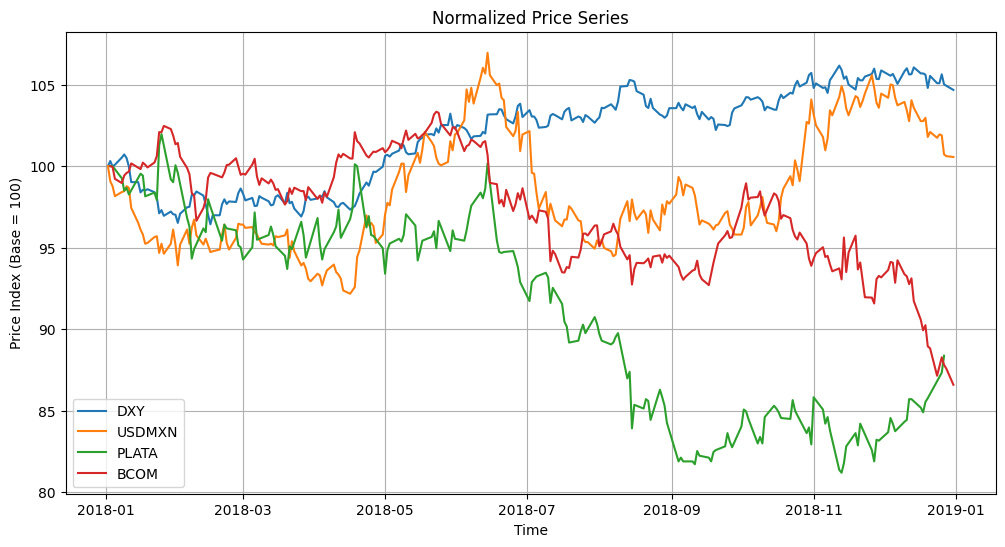

In [126]:
rrm.plot_normalized_timeseries(['DXY', 'USDMXN', 'PLATA','BCOM'], from_date = '2018-01-01', to_date='2018-12-31')

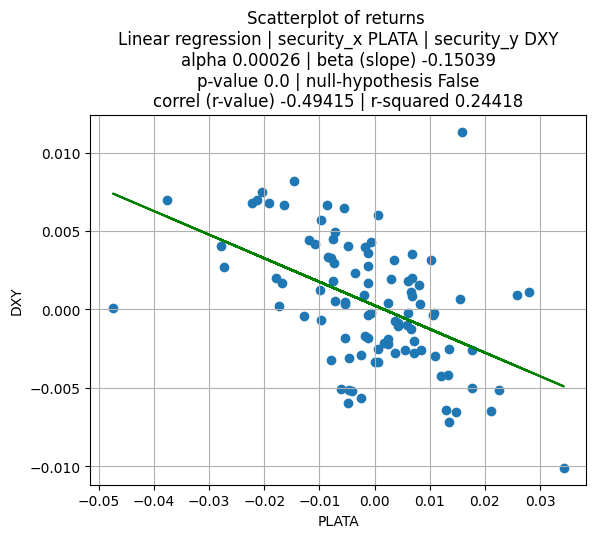

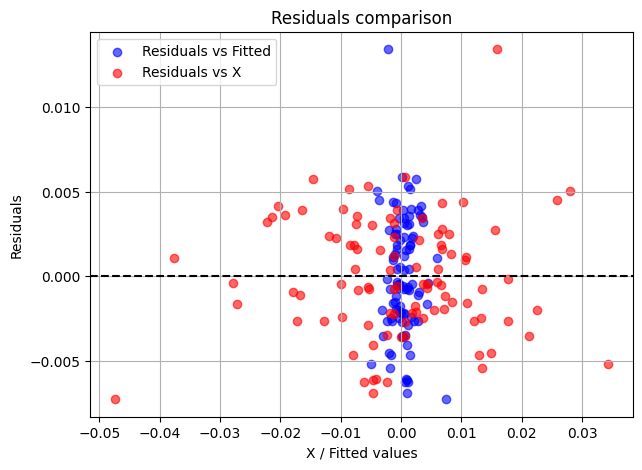

LINEALIDAD:
- OK: nube aleatoria sin patrón -> varianza no constante
- MAL: forma curva, tendencia o estructura visible

HOMOCEDASTICIDAD (Breusch-Pagan):
p-value: 0.62141
→ NO se rechaza H0: varianza constante

NORMALIDAD (Shapiro-Wilk):
p-value: 0.03575
→ Se RECHAZA H0: residuos NO normales

 INDEPENDENCIA (Durbin-Watson):
DW statistic: 2.12598
→ Sin evidencia de autocorrelación

Predicted b1 by the model: -0.15039
T test - t* de b1 : -5.568951917806087
Se rechaza H0 ( b1  =  0 ) tq b1 es diferente de  0 ya que 5.568951917806087 > 1.9849843115310182
Se rechaza H0 ( b1  >=  0 ) tq b1 < 0 ya que -5.568951917806087 < 1.6608814403008005


In [153]:
dxy_silver = rrm.model('PLATA', 'DXY', model_type='macro')
dxy_silver.synchronise_timeseries(from_date ='2018-01-02', to_date='2018-6-29') # from_date ='2018-07-02', to_date='2018-11-29'
dxy_silver.compute_linear_reg()
dxy_silver.plot_linear_reg()
dxy_silver.linealidad()
dxy_silver.homocedasticidad()
dxy_silver.normalidad()
dxy_silver.independencia()
dxy_silver.estimator_tests('b1')

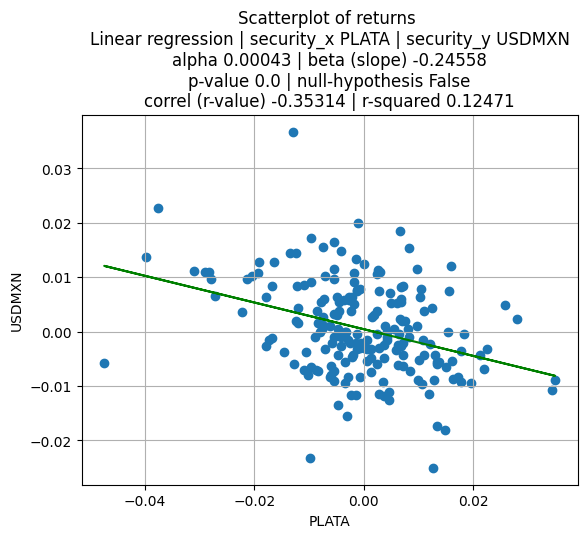

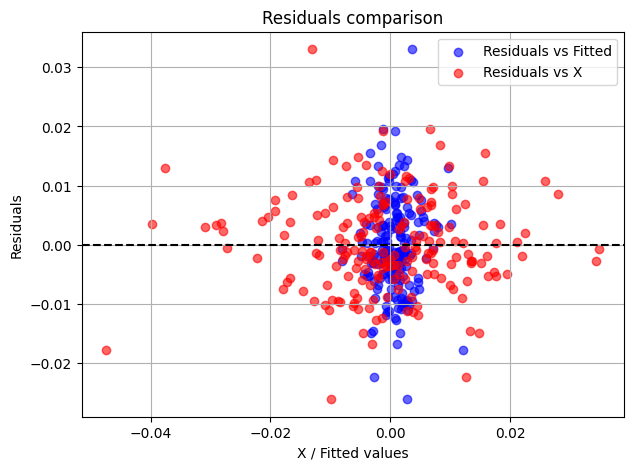

LINEALIDAD:
- OK: nube aleatoria sin patrón -> varianza no constante
- MAL: forma curva, tendencia o estructura visible

HOMOCEDASTICIDAD (Breusch-Pagan):
p-value: 0.21801
→ NO se rechaza H0: varianza constante

NORMALIDAD (Shapiro-Wilk):
p-value: 0.07019
→ NO se rechaza H0: residuos normales

 INDEPENDENCIA (Durbin-Watson):
DW statistic: 2.16253
→ Sin evidencia de autocorrelación

Predicted b1 by the model: -0.24558
T test - t* de b1 : -5.270906690478662
Se rechaza H0 ( b1  =  0 ) tq b1 es diferente de  0 ya que 5.270906690478662 > 1.9722040512658325
Se rechaza H0 ( b1  >=  0 ) tq b1 < 0 ya que -5.270906690478662 < 1.6527053097707547


In [155]:
usdmxn_silver = rrm.model('PLATA', 'USDMXN', model_type='macro')
usdmxn_silver.synchronise_timeseries(from_date ='2018-01-01', to_date='2018-12-29')
usdmxn_silver.compute_linear_reg()
usdmxn_silver.plot_linear_reg()
usdmxn_silver.linealidad()
usdmxn_silver.homocedasticidad()
usdmxn_silver.normalidad()
usdmxn_silver.independencia()
usdmxn_silver.estimator_tests('b1')

In [158]:
index_benchmarks = ['IBEX', 'SPX', 'MXX', 'NASDAQC']
r2_2018_index = rrm.buscar_mejor_r2(x = index_benchmarks, y = assets, start_date='2018-01-04', end_date='2018-12-31', min_obs = 80, min_corr=0.3)

In [159]:
# 1. Análisis
r2_2018_p_index, r2_2018_c_index = rrm.analizar_todo_el_df(r2_2018_index)

# 2. Resumen rápido
rrm.imprimir_resumen_frecuencias(r2_2018_index)

# 3. Desglose detallado de TODO
rrm.imprimir_desglose_total(r2_2018_p_index, titulo="DETALLE COMPLETO DEL SECURITY PRINCIPAL")
rrm.imprimir_desglose_total(r2_2018_c_index, titulo="DETALLE COMPLETO DEL COMPLEMENTO")


--- RESUMEN GENERAL DE ACTIVOS ---
El activo más frecuente es: USDMXN (60.00% de la base)
Mejor ajuste absoluto para el líder:
 > Sec: USDMXN | Bench: MXX
 > Score: 1.1106 | R2: 0.2493
 > Periodo: 2018-08-01 a 2018-11-30


█████████████████████████████████████████████████████████████████████████████████████
                       DETALLE COMPLETO DEL SECURITY PRINCIPAL                       
█████████████████████████████████████████████████████████████████████████████████████

💎 SECURITY: USDMXN (Total obs: 21)
   ═══════════════════════════════════════════════════════════════════════════
   🔸 Benchmark: MXX
      Frecuencia: 13 [61.90% del security]
      📉 Min R2: 0.1076 [r: -0.3280] (Score: 0.5650)
         Periodo: 2018-02-01 a 2018-11-01
      📈 Max R2: 0.2493 [r: -0.4993] (Score: 1.1106)
         Periodo: 2018-08-01 a 2018-11-30
      ····························································
   🔸 Benchmark: SPX
      Frecuencia: 7 [33.33% del security]
      📉 Min R2: 0.0941 

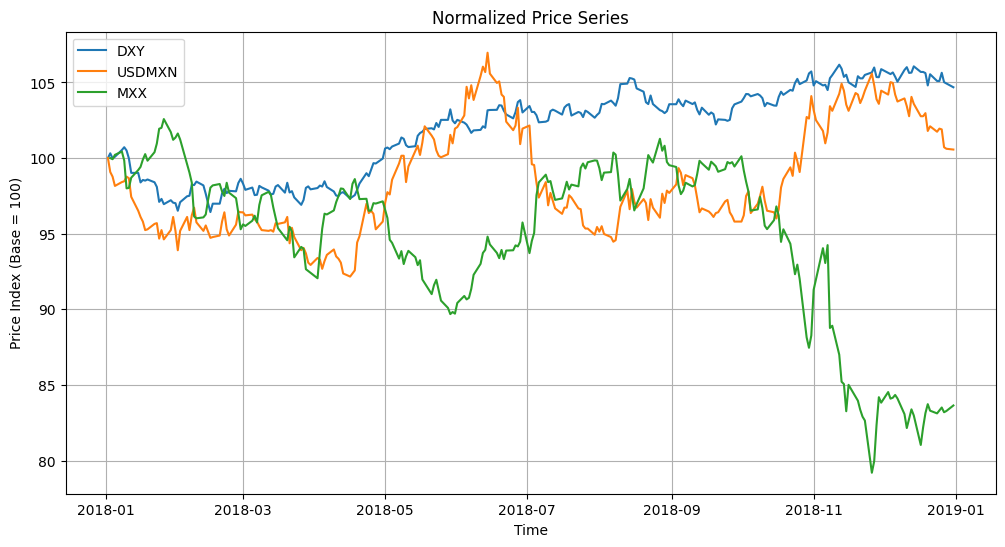

In [143]:
rrm.plot_normalized_timeseries(['DXY', 'USDMXN', 'MXX'], from_date = '2018-01-01', to_date='2018-12-31')

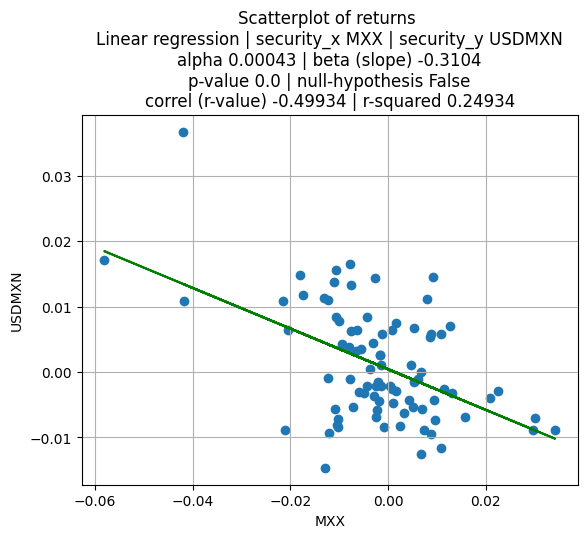

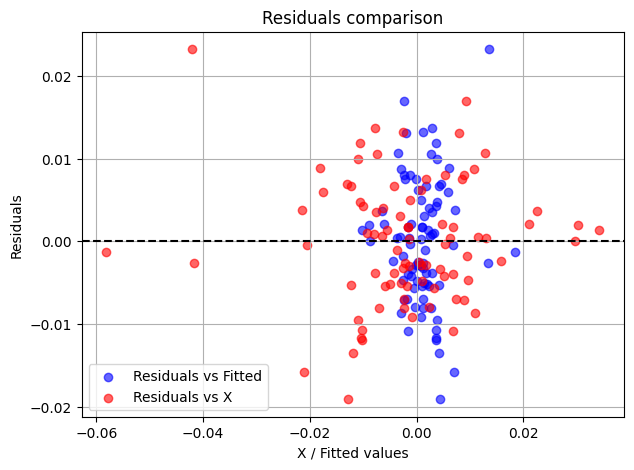

LINEALIDAD:
- OK: nube aleatoria sin patrón -> varianza no constante
- MAL: forma curva, tendencia o estructura visible

HOMOCEDASTICIDAD (Breusch-Pagan):
p-value: 0.00550
→ Se RECHAZA H0: hay heterocedasticidad (varianza NO constante)

NORMALIDAD (Shapiro-Wilk):
p-value: 0.96098
→ NO se rechaza H0: residuos normales

 INDEPENDENCIA (Durbin-Watson):
DW statistic: 2.39501
→ Sin evidencia de autocorrelación

Predicted b1 by the model: -0.3104
T test - t* de b1 : -5.282085270343771
Se rechaza H0 ( b1  =  0 ) tq b1 es diferente de  0 ya que 5.282085270343771 > 1.9886096669757087
Se rechaza H0 ( b1  >=  0 ) tq b1 < 0 ya que -5.282085270343771 < 1.6631966790019561


In [149]:
mxx_usdmxn = rrm.model('MXX', 'USDMXN', model_type='macro')
mxx_usdmxn.synchronise_timeseries(from_date ='2018-08-01', to_date='2018-11-30')
mxx_usdmxn.compute_linear_reg()
mxx_usdmxn.plot_linear_reg()
mxx_usdmxn.linealidad()
mxx_usdmxn.homocedasticidad()
mxx_usdmxn.normalidad()
mxx_usdmxn.independencia()
mxx_usdmxn.estimator_tests('b1')

### MXX vs USDMXN
Linealidad: parcialmente. La línea no está mal ajustada en el centro, pero hay varios problemas visibles:
1. Heterocedasticidad clara. Los residuos no tienen varianza constante. En la zona central (MXX cerca de 0) los puntos están muy dispersos verticalmente, mientras en los extremos se comprime. Eso viola el supuesto de homocedasticidad, que es un primo directo de la linealidad en regresión.
2. Outlier severo en la esquina superior izquierda. Ese punto aislado (MXX ≈ -0.06, USDMXN ≈ +0.036) está jalando la línea significativamente. Con solo 75-80 observaciones ese punto tiene palanca alta y está inflando artificialmente la pendiente negativa y el r² (0.249 en realidad se ve alto dado la nube de puntos).
3. La nube central es casi un círculo. Si tapas los outliers de los extremos, el resto de los puntos no muestran ninguna tendencia clara. La relación lineal la está "construyendo" principalmente los extremos, no la masa de datos.

El supuesto de linealidad se cumple débilmente. La relación existe pero es muy ruidosa (r2 de 0.25 con heterocedasticidad significa que en la práctica el modelo en el centro del rango no predice bien).

Winsorizar o eliminar el outlier extremo y recorrer la regresión para ver cuánto cambia el beta — si cambia mucho, tienes un problema de robustez.
Aplicar errores estándar robustos a heterocedasticidad (HC3 o Newey-West si hay autocorrelación).
Considerar si la relación es no lineal en los extremos — en crisis (MXX muy negativo) el dólar reacciona de forma no proporcional, lo que rompería la linealidad global.


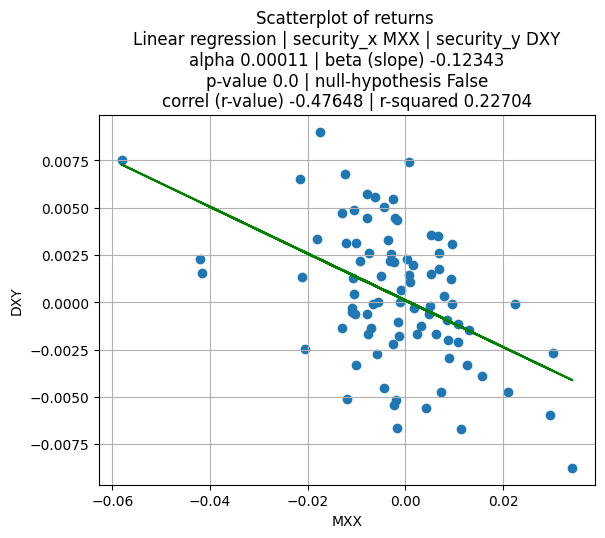

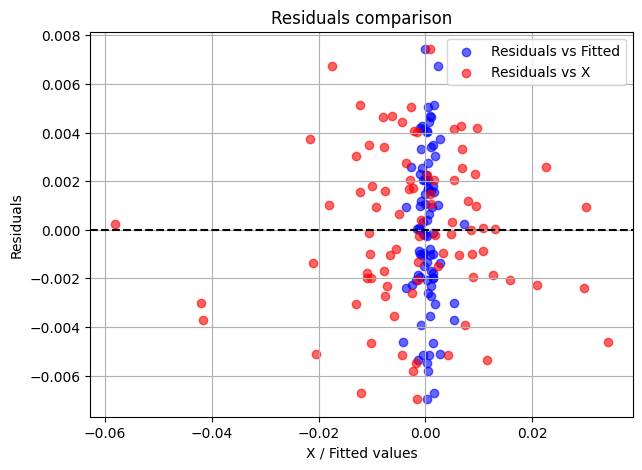

LINEALIDAD:
- OK: nube aleatoria sin patrón -> varianza no constante
- MAL: forma curva, tendencia o estructura visible

HOMOCEDASTICIDAD (Breusch-Pagan):
p-value: 0.41152
→ NO se rechaza H0: varianza constante

NORMALIDAD (Shapiro-Wilk):
p-value: 0.70621
→ NO se rechaza H0: residuos normales

 INDEPENDENCIA (Durbin-Watson):
DW statistic: 2.06786
→ Sin evidencia de autocorrelación

Predicted b1 by the model: -0.12343
T test - t* de b1 : -4.9672445906109095
Se rechaza H0 ( b1  =  0 ) tq b1 es diferente de  0 ya que 4.9672445906109095 > 1.9886096669757087
Se rechaza H0 ( b1  >=  0 ) tq b1 < 0 ya que -4.9672445906109095 < 1.6631966790019561


In [150]:
mxx_dxy = rrm.model('MXX', 'DXY', model_type='macro')
mxx_dxy.synchronise_timeseries(from_date ='2018-08-01', to_date='2018-11-30')
mxx_dxy.compute_linear_reg()
mxx_dxy.plot_linear_reg()
mxx_dxy.linealidad()
mxx_dxy.homocedasticidad()
mxx_dxy.normalidad()
mxx_dxy.independencia()
mxx_dxy.estimator_tests('b1')

### MXX vs DXY 
Parece cumplir supuestos pero...
Lo que mejora vs el gráfico MXX → USDMXN ✓
La nube es más simétrica y homogénea. Los puntos están mejor distribuidos alrededor de la línea en toda la extensión del eje X. La heterocedasticidad que era tan evidente en el anterior aquí es más moderada — la dispersión vertical en el centro es más parecida a la de los extremos.
Los outliers son menos dañinos. El punto extremo izquierdo (MXX ≈ -0.06) sigue ahí, pero su DXY correspondiente (≈ +0.0075) no es tan exagerado en escala relativa. En el gráfico anterior ese punto estaba claramente fuera del rango normal; aquí entra más dentro de la estructura general.

Lo que se mantiene preocupante ✗
El mismo problema de fondo: la masa central de puntos (MXX entre -0.01 y +0.01) sigue siendo una nube casi circular. La tendencia lineal la construyen principalmente los extremos.
r² de 0.227 — prácticamente igual al anterior (0.249). El DXY no explica mucho más ni mucho menos que el USDMXN en su relación con el MXX.
El beta es más pequeño (-0.123 vs -0.310), lo cual tiene sentido: el DXY es un índice del dólar contra una canasta de 6 monedas, por lo que el peso mexicano diluye su efecto. USDMXN es más sensible al MXX que el DXY en términos absolutos.


### Conclusiones
El DXY se comporta marginalmente mejor en términos de supuestos, pero ninguno de los dos pasa limpio un test de linealidad formal como RESET de Ramsey.

La pregunta de fondo para tu APT
¿Cuál es tu variable dependiente — USDMXN o DXY? Porque si tu objetivo es explicar el tipo de cambio peso-dólar, el USDMXN es el target correcto aunque tenga más ruido, ya que el DXY te estaría diluyendo el fenómeno que te interesa. El DXY podría ser más útil como factor explicativo (variable X) dentro del APT, no como el activo a explicar.

In [145]:
macro_rates_benchmarks = ['TIPS5', 'TIPS10', 'EXP_INF_USA5', 'EXP_INF_USA10', 'EXP_INF_MX3', 'EXP_INF_MX10']

r2_2018_macro = rrm.buscar_mejor_r2(x = macro_rates_benchmarks, y = assets, start_date='2018-01-04', end_date='2018-12-31', min_obs = 80, min_corr=0.3)

In [148]:
# 1. Análisis
r2_2018_p_macro, r2_2018_c_macro = rrm.analizar_todo_el_df(r2_2018_macro)

# 2. Resumen rápido
rrm.imprimir_resumen_frecuencias(r2_2018_macro)

# 3. Desglose detallado de TODO
rrm.imprimir_desglose_total(r2_2018_p_macro, titulo="DETALLE COMPLETO DEL SECURITY PRINCIPAL")
rrm.imprimir_desglose_total(r2_2018_c_macro, titulo="DETALLE COMPLETO DEL COMPLEMENTO")


--- RESUMEN GENERAL DE ACTIVOS ---
El activo más frecuente es: USDMXN (97.92% de la base)
Mejor ajuste absoluto para el líder:
 > Sec: USDMXN | Bench: EXP_INF_MX10
 > Score: 1.8783 | R2: 0.3734
 > Periodo: 2018-04-02 a 2018-11-01


█████████████████████████████████████████████████████████████████████████████████████
                       DETALLE COMPLETO DEL SECURITY PRINCIPAL                       
█████████████████████████████████████████████████████████████████████████████████████

💎 SECURITY: USDMXN (Total obs: 47)
   ═══════════════════════════════════════════════════════════════════════════
   🔸 Benchmark: EXP_INF_MX10
      Frecuencia: 28 [59.57% del security]
      📉 Min R2: 0.2194 [r: 0.4684] (Score: 1.0949)
         Periodo: 2018-02-01 a 2018-08-31
      📈 Max R2: 0.3986 [r: 0.6313] (Score: 1.7754)
         Periodo: 2018-08-01 a 2018-11-30
      ····························································
   🔸 Benchmark: EXP_INF_MX3
      Frecuencia: 19 [40.43% del security

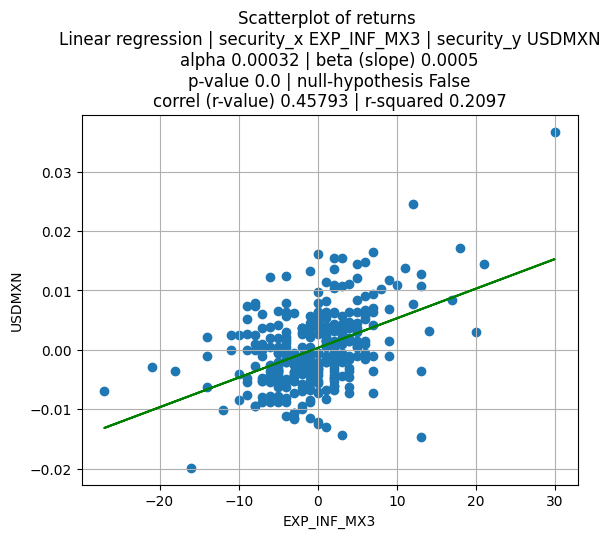

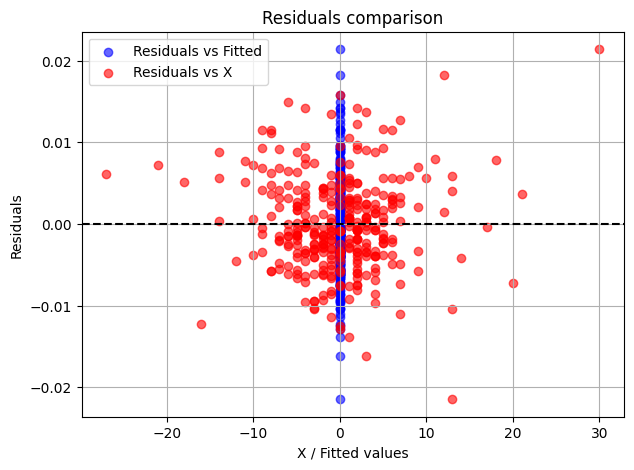

LINEALIDAD:
- OK: nube aleatoria sin patrón -> varianza no constante
- MAL: forma curva, tendencia o estructura visible

HOMOCEDASTICIDAD (Breusch-Pagan):
p-value: 0.00109
→ Se RECHAZA H0: hay heterocedasticidad (varianza NO constante)

NORMALIDAD (Shapiro-Wilk):
p-value: 0.01261
→ Se RECHAZA H0: residuos NO normales

 INDEPENDENCIA (Durbin-Watson):
DW statistic: 2.20760
→ Sin evidencia de autocorrelación

Predicted b1 by the model: 0.0005
T test - t* de b1 : 9.3978660027754
Se rechaza H0 ( b1  =  0 ) tq b1 es diferente de  0 ya que 9.3978660027754 > 1.9671350567188735
Se rechaza H0 ( b1  <=  0 ) tq b1 > 0 ya que 9.3978660027754 > 1.649456204654707


In [167]:
inf_mx_usdmxn = rrm.model('EXP_INF_MX3', 'USDMXN', model_type='macro')
inf_mx_usdmxn.synchronise_timeseries(from_date ='2018-08-01', to_date='2019-12-01')
inf_mx_usdmxn.compute_linear_reg()
inf_mx_usdmxn.plot_linear_reg()
inf_mx_usdmxn.linealidad()
inf_mx_usdmxn.homocedasticidad()
inf_mx_usdmxn.normalidad()
inf_mx_usdmxn.independencia()
inf_mx_usdmxn.estimator_tests('b1')

Analizando los supuestos observamos lo siguiente:
Antes del periodo    →  supuestos OK, R² bajo     →  no hay relación
Durante el periodo   →  supuestos fallan, R² alto  →  relación existe pero es no lineal o inestable
Después del periodo  →  supuestos OK, R² bajo      →  relación desapareció



Eso no es un modelo roto. Es un régimen transitorio. La relación existió, fue intensa, pero fue no lineal durante ese periodo — probablemente porque el mercado estaba en modo de ajuste violento (post-elección, NAICM, volatilidad del peso en mínimos históricos ese año). Los mercados en stress no se comportan linealmente.

Qué harías con esto
Opción 1 — Aceptar el hallazgo como régimen específico. Documentas que la relación USDMXN-Breakeven existió en ese periodo bajo condiciones de stress político-económico particular, pero no es una relación estructural estable. Eso tiene valor académico y práctico.
Opción 2 — Explorar no linealidad. Si dentro del subperiodo la homocedasticidad falla, considera si una transformación adicional o un modelo de umbral (threshold) captura mejor esa dinámica.
Opción 3 — Cambiar el target. Tu intuición es correcta. El breakeven de inflación a 3 años explicando USDMXN es una relación de segundo orden — el mercado de bonos indexados en México es relativamente ilíquido, entonces el breakeven puede moverse por razones técnicas más que por expectativas puras. Ese mismo factor podría explicar mejor activos más directamente ligados a inflación como Udibonos, TIIE, o incluso el propio INPC realizado. O bien activos sectoriales como bancos (BBVA, Banorte) que son sensibles a tasas.

In [170]:
# 1. Generar el análisis de temporalidad para todos los pares
# Esta función te devolverá un DataFrame con los mejores periodos de cada relación
df_temporalidad_2018 = rrm.analizar_temporalidad_todos_los_pares(r2_2018_macro)

# 2. Imprimir los resultados de forma legible en la consola
rrm.imprimir_mejores_periodos(df_temporalidad_2018)

# 3. (Opcional) Si quieres ver solo los top 5 con mayor score temporal de todo el año
print("\nTOP 5 RELACIONES MÁS SÓLIDAS DEL 2026:")
print(df_temporalidad_2018.nlargest(5, 'score_temporal'))


◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈
                  MEJORES VENTANAS TEMPORALES (R2 x DURACIÓN)                   
◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈

📊 SECURITY: DXY
   ▫ Bench: EXP_INF_MX3     | R2: 0.0927 | Días: 151 | Periodo: 2018-07-02 ➜ 2018-11-30

📊 SECURITY: USDMXN
   ▫ Bench: EXP_INF_MX10    | R2: 0.3009 | Días: 302 | Periodo: 2018-02-01 ➜ 2018-11-30
   ▫ Bench: EXP_INF_MX3     | R2: 0.1672 | Días: 302 | Periodo: 2018-02-01 ➜ 2018-11-30

◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈

TOP 5 RELACIONES MÁS SÓLIDAS DEL 2026:
  security     benchmark        r2  duracion_dias  score_temporal       from  \
1   USDMXN  EXP_INF_MX10  0.300877            302       90.864854 2018-02-01   
2   USDMXN   EXP_INF_MX3  0.167166            302       50.484132 2018-02-01   
0      DXY   EXP_INF_MX3  0.092692            151       13.996492 2018-07-02   

          to